# Auf dem Weg zur ersten Datenanalyse

## Notwendige Imports

In [211]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [212]:
print(np)
print(pd)
print(plt)
print(sns)


<module 'numpy' from 'c:\\Users\\raine\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\numpy\\__init__.py'>
<module 'pandas' from 'c:\\Users\\raine\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\pandas\\__init__.py'>
<module 'matplotlib.pyplot' from 'c:\\Users\\raine\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\matplotlib\\pyplot.py'>
<module 'seaborn' from 'c:\\Users\\raine\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\seaborn\\__init__.py'>


## Laden von Daten mit Pandas

* Das Pandas-Modul enthält eine Vielzahl von read_xyz-Funktionen, die Daten in verschiedensten Formaten lesen können

* Beispiel: Lokale csv-Datei

In [213]:
pd.read_csv('people.csv')

,Name,Weight,Height
0,Anna Neumann,55.8,165.0
1,Ben Wagner,78.6,180.0
2,Carla Weber,60.5,NaN
3,David Schmidt,85.5,185.0
4,Elena Zimmermann,52.5,160.0
5,Felix Schäfer,90.5,190.0
6,Gina Zimmermann,65.6,172.0
7,Hannes Hoffmann,72.4,178.0
8,Isabel Koch,58.8,167.0
9,Jonas Bauer,80.3,182.0


Beispiel: Lokale JSON-Datei

In [214]:
pd.read_json('people.json')

,id,lastname,firstname,gender,height
0,1,Sawitzki,Rainer,m,183
1,2,Meier,Hans,m,163
2,3,Metzger,Georg,m,190
3,4,Metzger,Frieda,f,167
4,5,Hoffmann,Hanna,f,155
5,6,Pausenkurt,Pascal,m,177
6,7,Fisch,Wanda,f,164
7,8,Ziegler,Thomas,m,193
8,9,Tost,Franziska,f,177
9,10,Berger,Hans,m,183


* Beispiel: Lesen einer JSON-Datei übers Intenet

In [215]:
pd.read_json('http://javacream.eu:8080/people')

,id,lastname,firstname,gender,height
0,1,Sawitzki,Rainer,m,183
1,2,Meier,Hans,m,163
2,3,Metzger,Georg,m,190
3,4,Metzger,Frieda,f,167
4,5,Hoffmann,Hanna,f,155
5,6,Pausenkurt,Pascal,m,177
6,7,Fisch,Wanda,f,164
7,8,Ziegler,Thomas,m,193
8,9,Tost,Franziska,f,177
9,10,Berger,Hans,m,183


* Beispiel: Lesen einer CSV-Datei vom Internet

In [216]:
pd.read_csv('https://raw.githubusercontent.com/lawlesst/vivo-sample-data/refs/heads/master/data/csv/people.csv')

,person_ID,name,first,last,middle,email,phone,fax,title
0,3130,"Burks, Rosella",Rosella,Burks,NaN,BurksR@univ.edu,963.555.1253,963.777.4065,Professor
1,3297,"Avila, Damien",Damien,Avila,NaN,AvilaD@univ.edu,963.555.1352,963.777.7914,Professor
2,3547,"Olsen, Robin",Robin,Olsen,NaN,OlsenR@univ.edu,963.555.1378,963.777.9262,Assistant Professor
3,1538,"Moises, Edgar Estes",Edgar,Moises,Estes,MoisesE@univ.edu,963.555.2731x3565,963.777.8264,Professor
4,2941,"Brian, Heath Pruitt",Heath,Brian,Pruitt,BrianH@univ.edu,963.555.2800,963.777.7249,Associate Curator
5,2401,"Claude, Elvin Haney",Elvin,Claude,Haney,ClaudeE@univ.edu,963.555.2902,963.777.9730,Curator
6,2070,"Mosley, Edmund",Edmund,Mosley,NaN,MosleyE@univ.edu,963.555.2945,963.777.9285,Assistant Professor
7,2561,"Derek, Antoine Mccoy",Antoine,Derek,Mccoy,DerekA@univ.edu,963.555.2992,963.777.5454,Curator
8,1625,"Hawkins, Callie",Callie,Hawkins,NaN,HawkinsC@univ.edu,963.555.3350x6480,963.777.4949,Professor
9,1307,"Pate, Andrea",Andrea,Pate,NaN,PateA@univ.edu,963.555.3723,963.777.5049,Professor


## Der Pandas DataFrame

* Im Endeffekt eine neue, sehr mächtige Collection
  * Die Methoden des DataFrames sind ausgerichte auf das Thema Exploration, Cleanup, ...
  * Neuinterpretation der Standard-Operatoren

### Erzeugung

In [217]:
# df = pd.read_csv('people.csv', index_col='Name')
df = pd.read_csv('people.csv')

### Exploration

In [218]:
df.head()

,Name,Weight,Height
0,Anna Neumann,55.8,165.0
1,Ben Wagner,78.6,180.0
2,Carla Weber,60.5,NaN
3,David Schmidt,85.5,185.0
4,Elena Zimmermann,52.5,160.0


In [219]:
df.tail()

,Name,Weight,Height
15,Paul Müller,79.2,181.0
16,Quinn Neumann,68.8,175.0
17,Ronja Müller,NaN,176.0
18,Samuel Schröder,83.7,184.0
19,Tina Fischer,59.7,168.0


In [220]:
df.shape

(20, 3)

In [221]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    20 non-null     object 
 1   Weight  17 non-null     float64
 2   Height  18 non-null     float64
dtypes: float64(2), object(1)
memory usage: 612.0+ bytes


In [222]:
print(df.columns)
print(df.dtypes)

Index(['Name', 'Weight', 'Height'], dtype='object')
Name       object
Weight    float64
Height    float64
dtype: object


### DataFrame als Collection

* Iteration
  * Nicht so häufig im Einsatz

In [223]:
for element in df['Weight']:
    print(element)

55.8
78.6
60.5
85.5
52.5
90.5
65.6
72.4
58.8
80.3
56.7
76.4
62.1
nan
nan
79.2
68.8
nan
83.7
59.7


### Index-Zugriff

In [224]:
df['Weight'][1]

np.float64(78.6)

In [225]:
# df['Weight'][1] = 42
df.loc[1, 'Weight'] = 42
df.head()

,Name,Weight,Height
0,Anna Neumann,55.8,165.0
1,Ben Wagner,42.0,180.0
2,Carla Weber,60.5,NaN
3,David Schmidt,85.5,185.0
4,Elena Zimmermann,52.5,160.0


### Selektion

In [226]:
criterion = df['Weight'] > 65
sub_df = df[criterion]
sub_df.head()

,Name,Weight,Height
3,David Schmidt,85.5,185.0
5,Felix Schäfer,90.5,190.0
6,Gina Zimmermann,65.6,172.0
7,Hannes Hoffmann,72.4,178.0
9,Jonas Bauer,80.3,182.0


In [227]:
df[df['Weight'] > 65]

,Name,Weight,Height
3,David Schmidt,85.5,185.0
5,Felix Schäfer,90.5,190.0
6,Gina Zimmermann,65.6,172.0
7,Hannes Hoffmann,72.4,178.0
9,Jonas Bauer,80.3,182.0
11,Lukas Fischer,76.4,179.0
15,Paul Müller,79.2,181.0
16,Quinn Neumann,68.8,175.0
18,Samuel Schröder,83.7,184.0


### Umgang mit NaN-Werten

In [228]:
df.isna()

,Name,Weight,Height
0,False,False,False
1,False,False,False
2,False,False,True
3,False,False,False
4,False,False,False
5,False,False,False
6,False,False,False
7,False,False,False
8,False,False,False
9,False,False,False


In [229]:
df['Weight'].isna()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13     True
14     True
15    False
16    False
17     True
18    False
19    False
Name: Weight, dtype: bool

In [230]:
df[df['Weight'].isna()]

,Name,Weight,Height
13,Nico Wolf,NaN,187.0
14,Olivia Schäfer,NaN,NaN
17,Ronja Müller,NaN,176.0


In [231]:
df[df['Weight'].isna()]


,Name,Weight,Height
13,Nico Wolf,NaN,187.0
14,Olivia Schäfer,NaN,NaN
17,Ronja Müller,NaN,176.0


In [232]:
df['Weight'].fillna(66, inplace=True)
df


C:\Users\raine\AppData\Local\Temp\ipykernel_12224\2331850160.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weight'].fillna(66, inplace=True)


,Name,Weight,Height
0,Anna Neumann,55.8,165.0
1,Ben Wagner,42.0,180.0
2,Carla Weber,60.5,NaN
3,David Schmidt,85.5,185.0
4,Elena Zimmermann,52.5,160.0
5,Felix Schäfer,90.5,190.0
6,Gina Zimmermann,65.6,172.0
7,Hannes Hoffmann,72.4,178.0
8,Isabel Koch,58.8,167.0
9,Jonas Bauer,80.3,182.0


In [233]:
df['Height'].ffill()

0     165.0
1     180.0
2     180.0
3     185.0
4     160.0
5     190.0
6     172.0
7     178.0
8     167.0
9     182.0
10    166.0
11    179.0
12    171.0
13    187.0
14    187.0
15    181.0
16    175.0
17    176.0
18    184.0
19    168.0
Name: Height, dtype: float64

* Entfernen einer ganzen Zeile / einer ganzen Spalte

In [234]:
df = pd.read_csv('people.csv')
df.dropna(axis=0, inplace=True)
df.shape

(16, 3)

### Analyse

In [235]:
df = pd.read_csv('people.csv')
df.describe()

,Weight,Height
count,17.000000,18.000000
mean,69.829412,175.888889
std,11.855577,8.456733
min,52.500000,160.000000
25%,59.700000,168.750000
50%,68.800000,177.000000
75%,79.200000,181.750000
max,90.500000,190.000000


array([[<Axes: title={'center': 'Height'}>]], dtype=object)

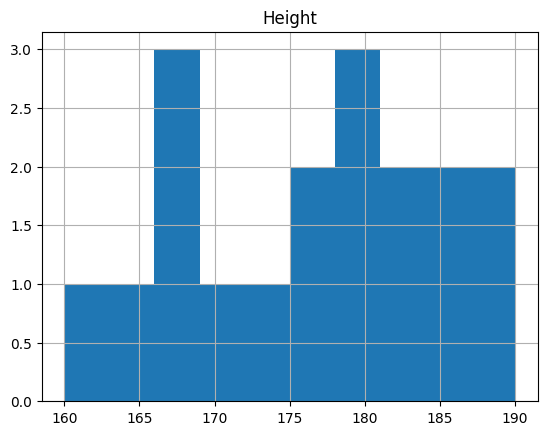

In [236]:
df.hist('Height')

<Axes: >

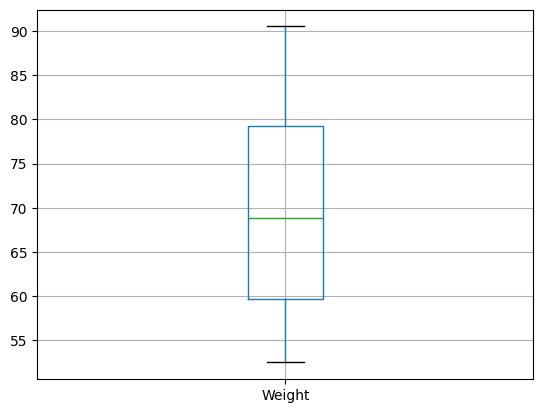

In [237]:
df.boxplot('Weight')

<Axes: >

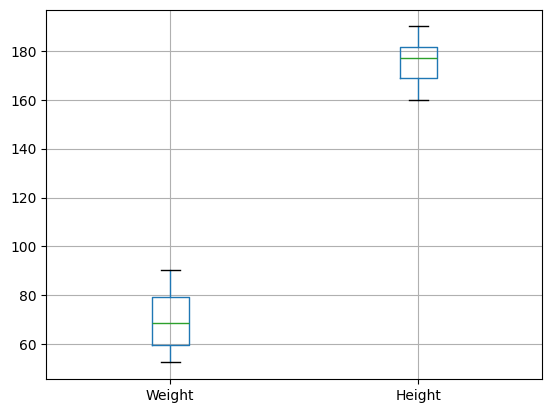

In [238]:
df.boxplot()